# HateXplain Audit: Fairness Analysis by Target Community

Dette notebooken gjennomfører en COMPAS-inspirert fairness-audit av HateXplain-datasettet.
Vi trener en logistisk regresjonsmodell og beregner *false positive rate* (FPR) og
*false negative rate* (FNR) per målgruppe — med særlig fokus på LGBTQ og
innvandringsrelaterte grupper som Meta liberaliserte i januar 2025.

**Forskningsspørsmål:** Hvilke grupper rammes uforholdsmessig av feilklassifisering
i et standard tekstklassifiseringsoppsett?

In [5]:
# !pip install scikit-learn matplotlib seaborn pandas numpy

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from itertools import chain

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)

classes = np.load("../data/classes.npy")
print("Class labels from classes.npy:", classes)

Class labels from classes.npy: ['hatespeech' 'normal' 'offensive']


## 1. Last inn HateXplain-datasettet

HateXplain (Mathew et al., 2021) inneholder ~20 000 Twitter/Gab-innlegg annotert av
tre annotatorer. Hvert innlegg har:
- `post_tokens`: tokenisert tekst
- `annotators`: liste med `label` (`hatespeech`/`offensive`/`normal`), annotator-id og målgruppe(r)
- `rationales`: binære arrays som markerer hvilke tokens som støttet avgjørelsen
- `post_id_divisions.json`: offisielle train/val/test-splits

In [7]:
with open("../data/dataset.json") as f:
    dataset = json.load(f)

with open("../data/post_id_divisions.json") as f:
    splits = json.load(f)

print(f"Totalt antall innlegg: {len(dataset)}")
print(f"Splits — train: {len(splits['train'])}, val: {len(splits['val'])}, test: {len(splits['test'])}")

# Inspiser ett eksempel
ex = dataset[splits["train"][0]]
print("\nEksempel-innlegg:")
print("  tokens:", ex["post_tokens"][:12], "...")
print("  annotators:", ex["annotators"])
print("  rationale shape:",
      f"{len(ex['rationales'])} annotatorer × {len(ex['rationales'][0]) if ex['rationales'] else 0} tokens")

Totalt antall innlegg: 20148
Splits — train: 15383, val: 1922, test: 1924

Eksempel-innlegg:
  tokens: ['u', 'really', 'think', 'i', 'would', 'not', 'have', 'been', 'raped', 'by', 'feral', 'hindu'] ...
  annotators: [{'label': 'hatespeech', 'annotator_id': 203, 'target': ['Hindu', 'Islam']}, {'label': 'offensive', 'annotator_id': 204, 'target': ['Hindu', 'Islam']}, {'label': 'offensive', 'annotator_id': 233, 'target': ['Hindu', 'Islam', 'Other']}]
  rationale shape: 2 annotatorer × 33 tokens


## 2. Forbehandling

Vi bruker hele datasettet (alle splits) siden vi evaluerer med kryssvalidering.
Etikett bestemmes ved flertallsavstemming blant de tre annotatorene.
Målgruppe per innlegg er union av alle annotatorers valgte grupper.

In [8]:
def majority_label(labels: list) -> str:
    """Flertallsstemme; uavgjort brytes av: hatespeech > offensive > normal."""
    count = Counter(labels)
    top_count = count.most_common(1)[0][1]
    candidates = [l for l, c in count.items() if c == top_count]
    for priority in ["hatespeech", "offensive", "normal"]:
        if priority in candidates:
            return priority

rows = []
for post_id, item in dataset.items():
    labels = [a["label"] for a in item["annotators"]]
    label  = majority_label(labels)

    targets = set(chain.from_iterable(a["target"] for a in item["annotators"]))
    targets.discard("None")

    text_len = len(item["post_tokens"])

    # Sum per annotator individually — one post has rationale arrays of unequal length
    if item["rationales"]:
        rationale_cnt = max(sum(r) for r in item["rationales"])
    else:
        rationale_cnt = 0

    rows.append({
        "post_id":       post_id,
        "label":         label,
        "targets":       list(targets),
        "text_len":      text_len,
        "rationale_cnt": rationale_cnt,
    })

df = pd.DataFrame(rows)
print("Shape:", df.shape)
print("\nEtikettfordeling:")
print(df["label"].value_counts())

Shape: (20148, 5)

Etikettfordeling:
label
normal        7814
hatespeech    6854
offensive     5480
Name: count, dtype: int64


In [9]:
# Binær etikett: 1 = hatespeech, 0 = offensive eller normal
df["y"] = (df["label"] == "hatespeech").astype(int)

print(f"Binær — hate=1: {df['y'].sum()} ({df['y'].mean():.1%})  |  other=0: {(df['y']==0).sum()}")

target_counts = Counter(chain.from_iterable(df["targets"]))
print("\nMålgruppe-fordeling (sortert):")
for t, n in sorted(target_counts.items(), key=lambda x: -x[1]):
    print(f"  {t:20s} {n}")

Binær — hate=1: 6854 (34.0%)  |  other=0: 13294

Målgruppe-fordeling (sortert):
  African              4468
  Women                3926
  Other                3702
  Islam                3201
  Homosexual           2596
  Jewish               2543
  Arab                 1784
  Refugee              1701
  Caucasian            1698
  Men                  1659
  Asian                727
  Hispanic             712
  Christian            208
  Minority             188
  Disability           153
  Heterosexual         141
  Nonreligious         87
  Indigenous           81
  Economic             81
  Indian               71
  Hindu                63
  Buddhism             10
  Bisexual             8
  Asexual              5


In [10]:
mlb = MultiLabelBinarizer()
target_matrix = mlb.fit_transform(df["targets"])
target_cols   = list(mlb.classes_)

df_targets = pd.DataFrame(target_matrix, columns=target_cols, index=df.index)

X = pd.concat([
    df_targets,
    df[["text_len", "rationale_cnt"]],
], axis=1).values

y = df["y"].values

print("Feature-matrise shape:", X.shape)
print("Kodede målgrupper:", target_cols)

Feature-matrise shape: (20148, 26)
Kodede målgrupper: ['African', 'Arab', 'Asexual', 'Asian', 'Bisexual', 'Buddhism', 'Caucasian', 'Christian', 'Disability', 'Economic', 'Heterosexual', 'Hindu', 'Hispanic', 'Homosexual', 'Indian', 'Indigenous', 'Islam', 'Jewish', 'Men', 'Minority', 'Nonreligious', 'Other', 'Refugee', 'Women']


## 3. Logistisk regresjonsmodell med kryssvalidering

Vi bruker samme metodikk som COMPAS-auditen: enkel logistisk regresjon med
5-fold stratifisert kryssvalidering. Enkelheten er et poeng — vi vil se hva
selv en "nøytral" standardmodell gjør med ulike grupper.

`class_weight="balanced"` kompenserer for at datasettet er noe ubalansert.

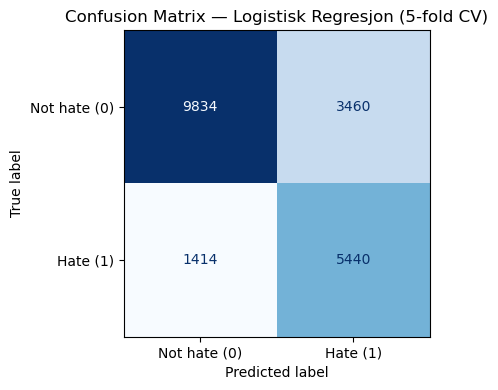

Overall FPR: 0.260  |  Overall FNR: 0.206


In [11]:
clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=SEED,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Out-of-fold prediksjoner for hvert innlegg
y_pred = cross_val_predict(clf, X, y, cv=cv, method="predict")

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not hate (0)", "Hate (1)"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Logistisk Regresjon (5-fold CV)")
plt.tight_layout()
plt.savefig("../figurer/confusion_matrix.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
overall_fpr = fp / (fp + tn)
overall_fnr = fn / (fn + tp)
print(f"Overall FPR: {overall_fpr:.3f}  |  Overall FNR: {overall_fnr:.3f}")

## 4. FPR og FNR per målgruppe

Samme som COMPAS-auditen (Angwin et al., 2016): vi beregner feilrater separat
for hvert subgruppe-subset. Et innlegg kan tilhøre flere grupper simultant.

- **FPR** (falsk positiv): ikke-hat klassifisert som hat → urettferdig sensurering
- **FNR** (falsk negativ): hat klassifisert som ikke-hat → hat slipper gjennom

Metas januar 2025-endring liberaliserte primært innhold rettet mot LGBTQ (`Homosexual`)
og innvandrere/religion (`Refugee`, `Arab`, `Islam`). Vi fremhever disse i rødt.

In [12]:
# Eksakte community-navn slik de fremstår i datasettet
META_LIBERALIZED = {"Homosexual", "Refugee", "Arab", "Islam"}

results = []
for community in target_cols:
    mask = df_targets[community].values == 1
    if mask.sum() < 30:  # hopp over svært sparsomme grupper
        continue

    y_sub      = y[mask]
    y_pred_sub = y_pred[mask]
    cm_sub     = confusion_matrix(y_sub, y_pred_sub, labels=[0, 1])

    if cm_sub.shape != (2, 2):
        continue

    tn_s, fp_s, fn_s, tp_s = cm_sub.ravel()
    fpr = fp_s / (fp_s + tn_s) if (fp_s + tn_s) > 0 else np.nan
    fnr = fn_s / (fn_s + tp_s) if (fn_s + tp_s) > 0 else np.nan

    results.append({
        "community":   community,
        "n":           int(mask.sum()),
        "n_hate":      int(y_sub.sum()),
        "FPR":         fpr,
        "FNR":         fnr,
        "meta_policy": community in META_LIBERALIZED,
    })

results_df = pd.DataFrame(results).sort_values("FNR", ascending=False)
print(results_df.to_string(index=False))

   community    n  n_hate      FPR      FNR  meta_policy
       Hindu   63      23 0.400000 0.434783        False
  Homosexual 2596    1013 0.189514 0.432379         True
       Other 3702    1074 0.244673 0.360335        False
       Asian  727     336 0.398977 0.354167        False
    Economic   81      19 0.129032 0.315789        False
   Caucasian 1698     529 0.302823 0.315690        False
    Hispanic  712     418 0.721088 0.313397        False
     Refugee 1701     624 0.313835 0.301282         True
   Christian  208      84 0.459677 0.273810        False
       Women 3926    1236 0.246097 0.252427        False
         Men 1659     538 0.351472 0.241636        False
  Indigenous   81      47 0.676471 0.212766        False
  Disability  153      63 0.188889 0.190476        False
      Indian   71      44 0.888889 0.159091        False
Heterosexual  141      63 0.294872 0.126984        False
        Arab 1784    1119 0.810526 0.088472         True
       Islam 3201    1785 0.823

/var/folders/x5/k71n0vsx49bbvxqh77hmyxc00000gn/T/ipykernel_30618/1185154444.py:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(plot_df["community"], rotation=40, ha="right", fontsize=9)


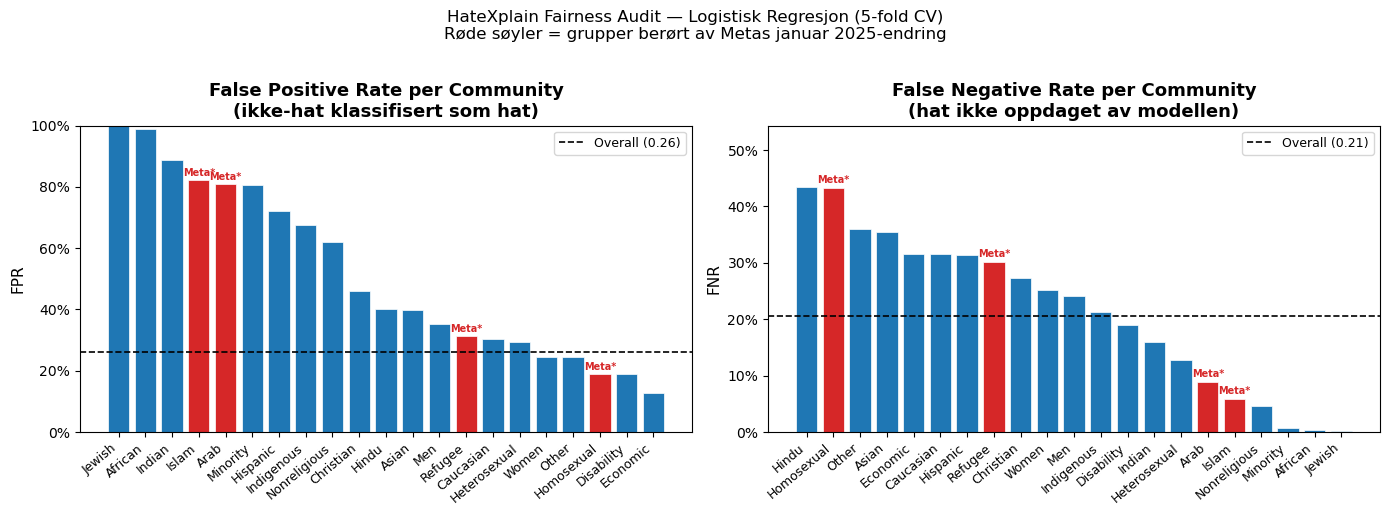

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def make_bar(ax, col, title, overall_val):
    plot_df = results_df.sort_values(col, ascending=False).copy()
    colors  = ["#d62728" if m else "#1f77b4" for m in plot_df["meta_policy"]]

    bars = ax.bar(plot_df["community"], plot_df[col],
                  color=colors, edgecolor="white", linewidth=0.5)
    ax.axhline(overall_val, color="black", linestyle="--", linewidth=1.2,
               label=f"Overall ({overall_val:.2f})")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(col, fontsize=11)
    ax.set_ylim(0, min(1.0, plot_df[col].max() * 1.25))
    ax.set_xticklabels(plot_df["community"], rotation=40, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(fontsize=9)

    for bar, is_meta in zip(bars, plot_df["meta_policy"]):
        if is_meta:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    "Meta*", ha="center", va="bottom",
                    fontsize=7, color="#d62728", fontweight="bold")

make_bar(axes[0], "FPR",
         "False Positive Rate per Community\n(ikke-hat klassifisert som hat)",
         overall_fpr)
make_bar(axes[1], "FNR",
         "False Negative Rate per Community\n(hat ikke oppdaget av modellen)",
         overall_fnr)

fig.suptitle(
    "HateXplain Fairness Audit — Logistisk Regresjon (5-fold CV)\n"
    "Røde søyler = grupper berørt av Metas januar 2025-endring",
    fontsize=12, y=1.02
)

plt.tight_layout()
plt.savefig("../figurer/fpr_fnr_by_community.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Annotatøruenighet per gruppe

En viktig dimensjon som skiller HateXplain fra COMPAS: vi kan måle hvor *usikre* mennesker
er på grensen mellom hat og offensivt innhold. Høy annotatøruenighet indikerer at innholdet
er i gråsonen — nettopp det Meta kaller Tier 2.

Vi beregner andelen innlegg per gruppe der de tre annotatorene **ikke** er enige.

Andel innlegg med uenighet: 51.1%


/var/folders/x5/k71n0vsx49bbvxqh77hmyxc00000gn/T/ipykernel_30618/794070723.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(disagree_df["community"], rotation=40, ha="right", fontsize=9)


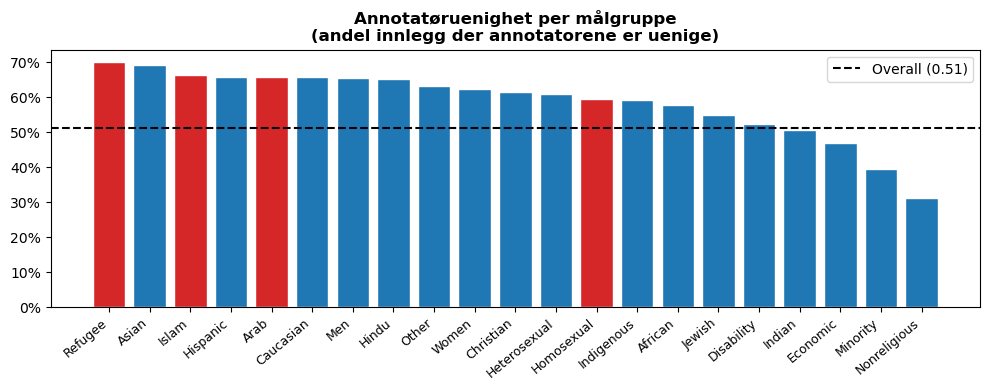

In [14]:
def annotator_disagreement(labels: list) -> bool:
    """True hvis ikke alle tre annotatorer er enige."""
    return len(set(labels)) > 1

df["disagreement"] = [
    annotator_disagreement([a["label"] for a in dataset[pid]["annotators"]])
    for pid in df["post_id"]
]

print(f"Andel innlegg med uenighet: {df['disagreement'].mean():.1%}")

disagree_per_group = []
for community in target_cols:
    mask = df_targets[community].values == 1
    if mask.sum() < 30:
        continue
    rate = df["disagreement"].values[mask].mean()
    disagree_per_group.append({"community": community, "disagreement_rate": rate,
                                "meta_policy": community in META_LIBERALIZED})

disagree_df = pd.DataFrame(disagree_per_group).sort_values("disagreement_rate", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#d62728" if m else "#1f77b4" for m in disagree_df["meta_policy"]]
ax.bar(disagree_df["community"], disagree_df["disagreement_rate"],
       color=colors, edgecolor="white")
ax.axhline(df["disagreement"].mean(), color="black", linestyle="--",
           label=f"Overall ({df['disagreement'].mean():.2f})")
ax.set_title("Annotatøruenighet per målgruppe\n(andel innlegg der annotatorene er uenige)",
             fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xticklabels(disagree_df["community"], rotation=40, ha="right", fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig("../figurer/disagreement_by_community.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Tolkning

Resultatene over viser at feilratene varierer betydelig mellom grupper —
analogt med COMPAS-funnene for rase. Spesielt:

- **Høy FNR** for en gruppe betyr at hatytringer mot den gruppen systematisk
  *unnslipper* deteksjon — modellen er for ettergivende.
- **Høy FPR** betyr at uskyldig innhold rettet mot gruppen feiltolkes som hat —
  modellen risikerer å sensurere legitim diskurs.
- **Høy annotatøruenighet** bekrefter at grensetilfellene (Tier 2 i Metas system)
  er genuine tvetydigheter, ikke bare målefeil.

Metas liberalisering av Tier 2-regler for LGBTQ og innvandringsrelaterte grupper
øker den effektive terskelen for hva som flagges. I lys av resultatene betyr
dette at innhold som *allerede er vanskeligere å klassifisere* nå også møter lavere
plattformrespons — en dobbel eksponering for gruppene som er mest utsatt.

> **Begrensning:** Logistisk regresjon med enkle features er bevisst naiv.
> En produksjonsmodell (f.eks. fine-tunet BERT) vil ha lavere feilrater totalt,
> men *skjevheten mellom grupper* er typisk robust på tvers av modellkompleksitet
> (Mozafari et al., 2020).

In [15]:
# Sammendragstabell egnet for papir
summary = results_df.merge(
    disagree_df[["community", "disagreement_rate"]],
    on="community", how="left"
)[["community", "n", "n_hate", "FPR", "FNR", "disagreement_rate", "meta_policy"]].copy()

summary.columns = ["Community", "N", "N hate", "FPR", "FNR", "Disagreement", "Meta Jan-2025"]
summary["FPR"]         = summary["FPR"].map(lambda x: f"{x:.3f}")
summary["FNR"]         = summary["FNR"].map(lambda x: f"{x:.3f}")
summary["Disagreement"] = summary["Disagreement"].map(lambda x: f"{x:.3f}")
summary["Meta Jan-2025"] = summary["Meta Jan-2025"].map(lambda x: "Yes" if x else "")

print(summary.to_string(index=False))

# Eksporter til LaTeX ved behov:
# print(summary.to_latex(index=False, escape=False))

   Community    N  N hate   FPR   FNR Disagreement Meta Jan-2025
       Hindu   63      23 0.400 0.435        0.651              
  Homosexual 2596    1013 0.190 0.432        0.594           Yes
       Other 3702    1074 0.245 0.360        0.632              
       Asian  727     336 0.399 0.354        0.692              
    Economic   81      19 0.129 0.316        0.469              
   Caucasian 1698     529 0.303 0.316        0.656              
    Hispanic  712     418 0.721 0.313        0.659              
     Refugee 1701     624 0.314 0.301        0.700           Yes
   Christian  208      84 0.460 0.274        0.615              
       Women 3926    1236 0.246 0.252        0.622              
         Men 1659     538 0.351 0.242        0.653              
  Indigenous   81      47 0.676 0.213        0.593              
  Disability  153      63 0.189 0.190        0.523              
      Indian   71      44 0.889 0.159        0.507              
Heterosexual  141      63